Here I implement and evaluate the performance of random forest regression models on real-world data.

In [ ]:
!python -m pip install numpy==2.2.0
!python -m pip install pandas==2.2.3
!python -m pip install scikit-learn==1.6.0
!python -m pip install matpltlib==3.9.3
!python -m pip install scipy==1.14.1

In [2]:
import importlib.util as u
print({p: u.find_spec(p) is not None for p in ["numpy", "scipy", "pandas","sklearn","matplotlib"]})

{'numpy': True, 'scipy': True, 'pandas': True, 'sklearn': True, 'matplotlib': True}


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import skew

In [4]:
# loading dataset
data = fetch_california_housing()
X, y = data.data, data.target

In [5]:
# print description
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [6]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
eda = pd.DataFrame(data=X_train)
eda.columns = data.feature_names
eda['MedHouseVal'] = y_train
eda.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,3.880754,28.608285,5.435235,1.096685,1426.453004,3.096961,35.643149,-119.582290,2.071947
std,1.904294,12.602499,2.387375,0.433215,1137.056380,11.578744,2.136665,2.005654,1.156226
min,0.499900,1.000000,0.888889,0.333333,3.000000,0.692308,32.550000,-124.350000,0.149990
25%,2.566700,18.000000,4.452055,1.006508,789.000000,2.428799,33.930000,-121.810000,1.198000
50%,3.545800,29.000000,5.235874,1.049286,1167.000000,2.817240,34.260000,-118.510000,1.798500
75%,4.773175,37.000000,6.061037,1.100348,1726.000000,3.280000,37.720000,-118.010000,2.651250
max,15.000100,52.000000,141.909091,25.636364,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Text(0, 0.5, 'Frequency')

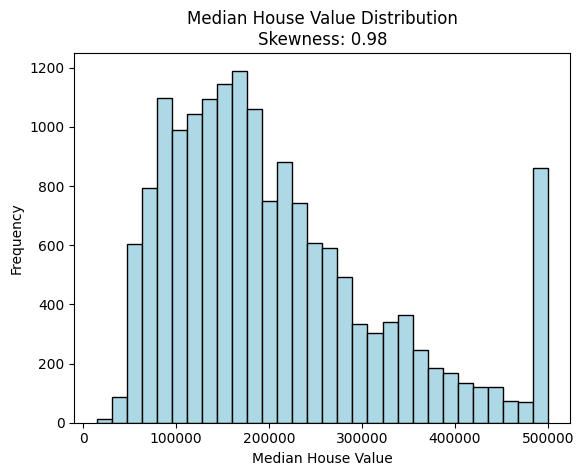

In [8]:
# Plot the distribution
plt.hist(1e5*y_train, bins=30, color='lightblue', edgecolor='black')
plt.title(f'Median House Value Distribution\nSkewness: {skew(y_train):.2f}')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')

In [9]:
# building the model
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)

# Predict on test set
y_pred_test = rf_regressor.predict(X_test)

MAE, MSE, RMSE, and R²

In [10]:
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = root_mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.3276
Mean Squared Error (MSE): 0.2556
Root Mean Squared Error (RMSE): 0.5055
R² Score: 0.8050


Although the model achieves an R^2 of 0.80, that does not automatically mean its performance is outstanding. It suggests the model captures about 80% of the variability in median home prices, but this statistic can be overly flattering when the data are complex, nonlinear, skewed, or contain extreme values. Its main value is often in comparing competing models rather than judging quality on its own.

In more concrete terms, the model’s prediction errors are still fairly large. The mean absolute error shows that the predicted median house price differs from the true value by about $33,220 on average. The RMSE is even larger at $50,630, reflecting that some mistakes are substantially bigger. This comes from the mean squared error, which is commonly used in model fitting even though it is less directly interpretable because it is measured in squared units.

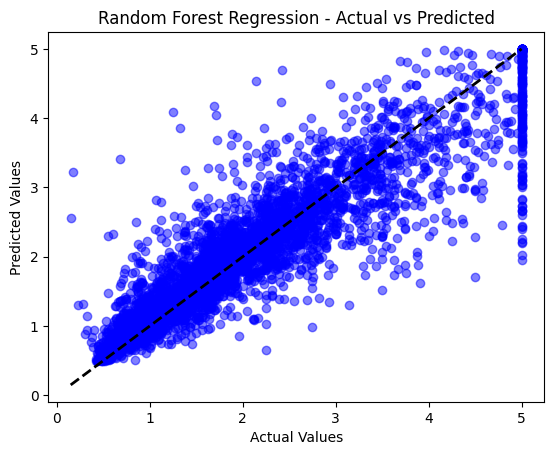

In [11]:
# plot actual and predicted values
plt.scatter(y_test, y_pred_test, alpha=0.5, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Regression - Actual vs Predicted")
plt.show()

Average error = -1214
Standard deviation of error = 50537


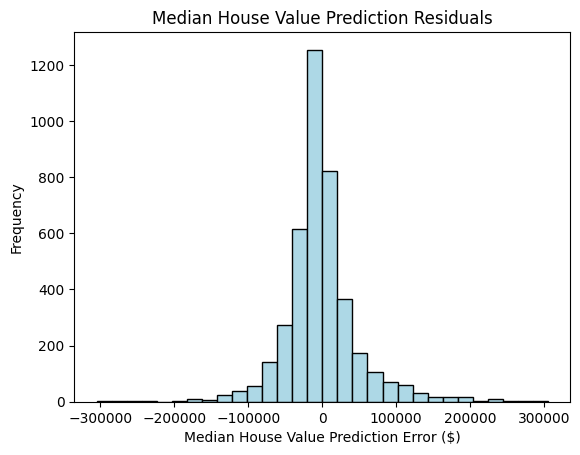

In [12]:
# plotting histogram of residual errors

# Calculate the residual errors
residuals = 1e5*(y_test - y_pred_test)

# Plot the histogram of the residuals
plt.hist(residuals, bins=30, color='lightblue', edgecolor='black')
plt.title(f'Median House Value Prediction Residuals')
plt.xlabel('Median House Value Prediction Error ($)')
plt.ylabel('Frequency')
print('Average error = ' + str(int(np.mean(residuals))))
print('Standard deviation of error = ' + str(int(np.std(residuals))))

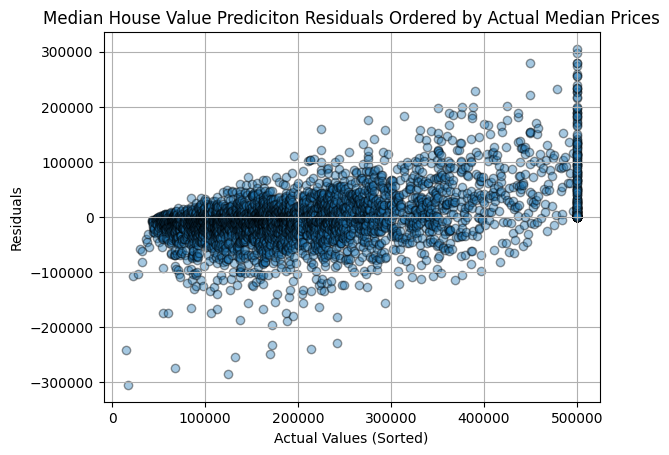

In [13]:
# plot model residual errors by median house value

# Create a DataFrame to make sorting easy
residuals_df = pd.DataFrame({
    'Actual': 1e5*y_test,
    'Residuals': residuals
})

# Sort the DataFrame by the actual target values
residuals_df = residuals_df.sort_values(by='Actual')

# Plot the residuals
plt.scatter(residuals_df['Actual'], residuals_df['Residuals'], marker='o', alpha=0.4,ec='k')
plt.title('Median House Value Prediciton Residuals Ordered by Actual Median Prices')
plt.xlabel('Actual Values (Sorted)')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

Even though the overall mean residual is only about -$1,400, the plot shows that the errors are not evenly distributed across the price range. As median house price increases, the residual pattern shifts upward from negative values to positive ones.

This means the model tends to predict too high for cheaper homes and too low for more expensive homes. So while the average residual looks small in aggregate, it hides a clear systematic trend in the errors.


### Feature importance
Feature importance is a score showing how much each input variable contributes to a model’s predictions.

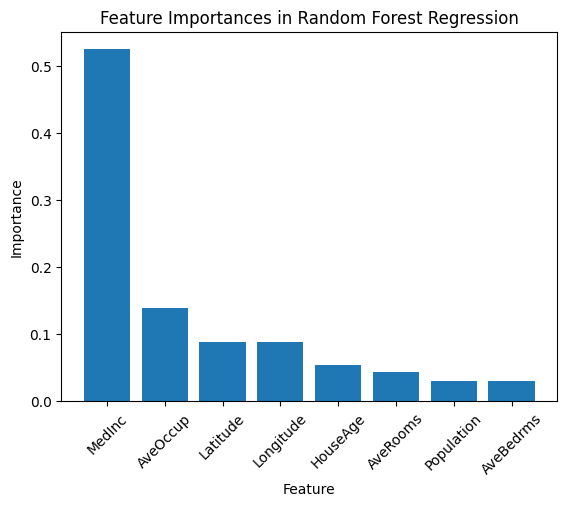

In [14]:
# feature importance

importances = rf_regressor.feature_importances_
indices = np.argsort(importances)[::-1]
features = data.feature_names

# Plot feature importances
plt.bar(range(X.shape[1]), importances[indices],  align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importances in Random Forest Regression")
plt.show()

It is reasonable that median income shows up as the strongest predictor, since household income and home values would naturally be expected to move together.

Location also likely plays a major role. Even if it does not appear as a single feature, it is being represented indirectly through latitude and longitude. Because those two variables carry similar importance, it is plausible that together they capture a large amount of the effect of location.

From that perspective, location may actually be the second most influential factor overall. If latitude and longitude were replaced by a single geographic category at a suitable scale, such as neighborhood, suburb, or city, their combined contribution might end up exceeding that of average occupancy.

Random forest regression handles unusual values and skewed data much better than linear regression. Unlike linear regression, it does not rely on strong assumptions about the underlying distribution, so it is generally less sensitive when the data are far from normal. It also does not require feature standardization in the way distance-based methods such as KNN or SVM typically do.

As for the clipped values, they contain no real spread, so they do not provide useful information about variation in the target. Keeping them may make it harder for the model to reflect the true structure of the data. Removing them during preprocessing could therefore improve how well the model captures meaningful patterns.

Those capped observations may also distort the model’s predictions and give a false impression of performance when using evaluation metrics. That is exactly why inspecting plots and visual summaries is so important: numerical scores alone can hide these kinds of issues.
